# Why Gradient Descent Zigzags — and How Momentum Fixes It
Gradient descent has a fundamental limitation: on most real-world loss surfaces, it is inefficient. When the surface has uneven curvature—steep in one direction and flat in another, which is common in practice—the algorithm struggles to make consistent progress. A high learning rate helps move faster along the flat direction but causes overshooting and oscillations along the steep direction. Reducing the learning rate stabilizes the updates but significantly slows convergence. This trade-off is not rare; it is typical behavior for standard gradient descent.

Momentum addresses this issue by incorporating information from past gradients. Instead of relying only on the current gradient, it maintains a running average (often called velocity) and updates parameters based on this accumulated direction. As a result, consistent gradients reinforce each other, allowing faster movement across flat regions, while oscillating gradients tend to cancel out, reducing instability.

In this article, we walk through exactly how this works: the update equations, and a from-scratch simulation on a controlled anisotropic surface that lets us measure the difference precisely — 185 steps for vanilla GD versus 159 for Momentum, with β=0.99 failing to converge entirely.


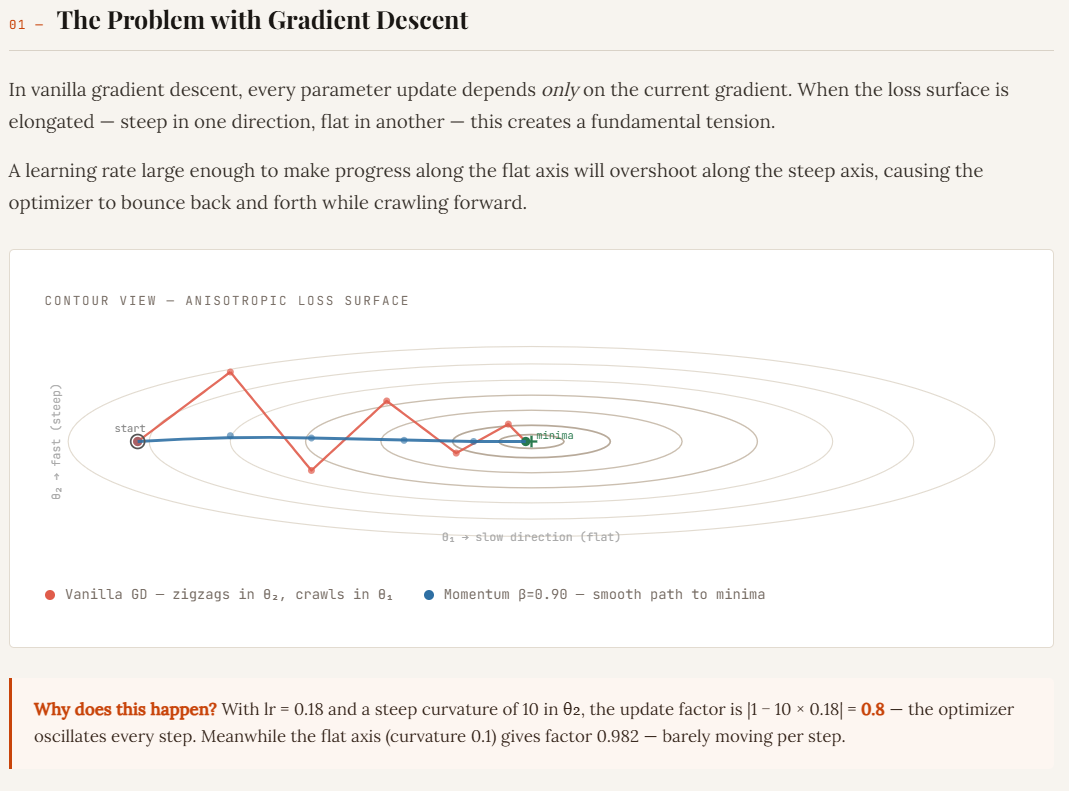

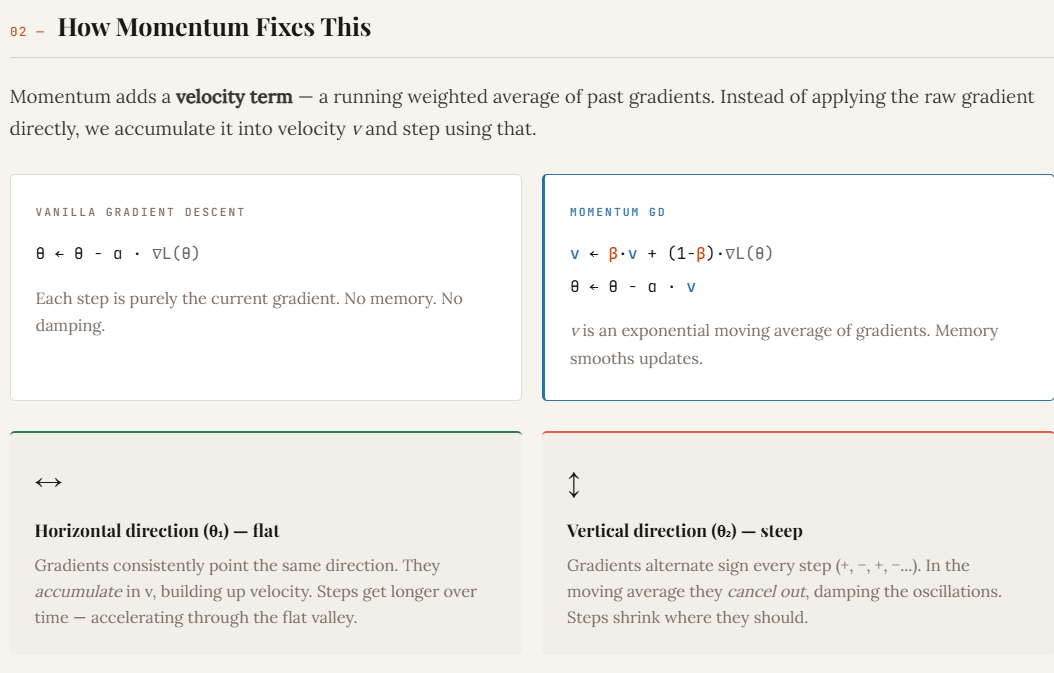

## Setting up the dependencies

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Defining the Loss Surface
The loss surface is a stretched bowl — flat along one axis, steep along the other. This is controlled by the two coefficients: 0.05 in x makes that direction nearly flat, while 5 in y makes it steep. The gradients reflect this directly — 0.1·x in the flat direction, 10·y in the steep one.

The Hessian of this surface is diagonal with eigenvalues 0.1 and 10, giving a condition number of 100. That number is the core of the problem: it tells you the surface is 100× more curved in one direction than the other, which is what forces GD into its zigzag behavior.

The learning rate of 0.18 is chosen deliberately. The stability limit for GD is 2 / λ_max = 2 / 10 = 0.2 — any higher and the optimizer diverges outright. At 0.18, the steep axis update factor is |1 − 10 × 0.18| = 0.8, meaning the optimizer overshoots and reverses direction every single step. The flat axis factor is |1 − 0.1 × 0.18| = 0.982, meaning it recovers only 1.8% of the remaining distance per step. This is the worst-case combination Momentum is built for: oscillation in one direction, near-stagnation in the other.

In [5]:
def loss(x, y):
    return 0.05 * x**2 + 5 * y**2

def grad(x, y):
    return np.array([0.1 * x, 10 * y])

## Optimizers
Both methods follow the same overall process: start from an initial position, take a fixed number of steps, and track how the position changes. The key difference lies in how each step is computed.

Vanilla gradient descent is very simple. At each step, it updates the position by subtracting the gradient scaled by the learning rate. It does not remember anything from previous steps. This is why oscillations occur—if the gradient direction keeps changing (up, then down), the updates simply follow that pattern with no mechanism to smooth it out.

Momentum introduces one additional term: velocity (v), which is initially zero. Instead of using only the current gradient, it updates this velocity by combining the previous velocity and the new gradient. The parameter β controls how much weight is given to past information. A higher β (e.g., 0.9) means the update relies more on past gradients, while a lower β makes it behave more like standard gradient descent.

This averaging effect behaves differently across directions. In steep directions, where gradients frequently change sign, the updates tend to cancel each other out, reducing oscillations. In flatter directions, where gradients are more consistent, they accumulate over time, allowing the optimizer to move faster.

Finally, the position is updated using this velocity instead of the raw gradient. This results in smoother and more stable progress toward the minimum.

In [6]:
def gradient_descent(start, lr, steps=300):
    """
    Vanilla GD:  θ ← θ − lr · ∇L(θ)

    Each update depends only on the current gradient.
    No memory of past gradients — oscillations persist.
    """
    path = [np.array(start, dtype=float)]
    pos  = np.array(start, dtype=float)
    for _ in range(steps):
        pos = pos - lr * grad(*pos)
        path.append(pos.copy())
    return np.array(path)


def momentum_gd(start, lr, beta, steps=300):
    """
    Momentum GD:
        v ← β·v + (1−β)·∇L(θ)
        θ ← θ − lr·v

    v is a weighted running average of past gradients (exponential moving avg).

    Why it helps:
      - In y: gradients alternate sign → they cancel in v → oscillations damped.
      - In x: gradients share the same sign → they accumulate in v → faster steps.

    β controls memory length. High β → longer memory → more smoothing (and risk
    of overshooting). Low β → shorter memory → closer to vanilla GD.
    """
    path = [np.array(start, dtype=float)]
    pos  = np.array(start, dtype=float)
    v    = np.zeros(2)
    for _ in range(steps):
        g   = grad(*pos)
        v   = beta * v + (1 - beta) * g
        pos = pos - lr * v
        path.append(pos.copy())
    return np.array(path)


## Running all three scenarios
All three experiments start from the same point (−4.0, 1.5), use the same learning rate, and run for 300 steps. The only difference is the use of momentum and the value of β. Instead of just recording the final position, the full trajectory is stored for each run, which allows us to analyze how the optimizer moves over time. Vanilla gradient descent progresses slowly with a zigzag pattern and reaches a final loss of 0.000015. Momentum with β = 0.90 performs more efficiently, reducing oscillations and building speed in the right direction, ultimately achieving a lower loss of 0.000001 within the same number of steps.

However, momentum is sensitive to the choice of β. When β is set too high (e.g., 0.99), the optimizer accumulates excessive velocity with very little decay. This leads to overshooting the minimum and failing to stabilize, resulting in a much higher final loss of 0.487363 even after 300 steps. In this case, the optimizer effectively keeps circling the minimum without converging. These results highlight that while momentum can significantly improve convergence, it must be carefully tuned—too little offers no benefit over standard gradient descent, while too much introduces instability.

In [7]:
START = [-4.0, 1.5]
LR    = 0.18
STEPS = 300

path_gd        = gradient_descent(START, lr=LR,           steps=STEPS)
path_mom_good  = momentum_gd(START,      lr=LR, beta=0.90, steps=STEPS)
path_mom_large = momentum_gd(START,      lr=LR, beta=0.99, steps=STEPS)

print(f"Vanilla GD        — final loss: {loss(*path_gd[-1]):.6f}")
print(f"Momentum β=0.90   — final loss: {loss(*path_mom_good[-1]):.6f}")
print(f"Momentum β=0.99   — final loss: {loss(*path_mom_large[-1]):.6f}  ← diverges")

Vanilla GD        — final loss: 0.000015
Momentum β=0.90   — final loss: 0.000001
Momentum β=0.99   — final loss: 0.487363  ← diverges


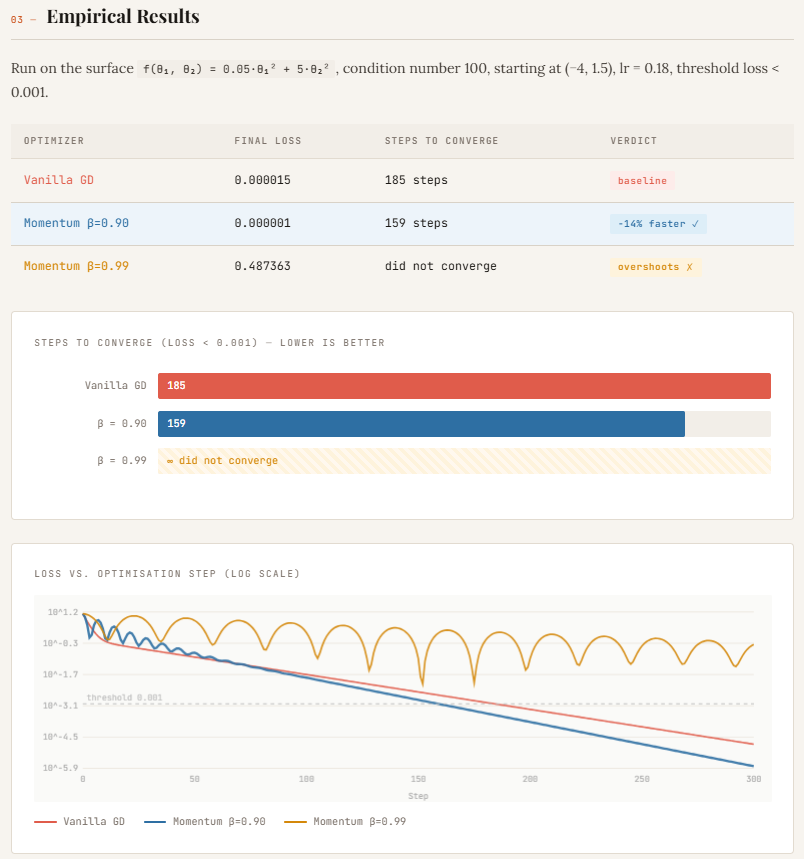

## Visualizing the Result
The visualization is divided into two parts. The top row shows the first 55 steps of each optimizer plotted on the contour map of the loss surface, making it easier to observe movement patterns without clutter. The bottom row displays the full 300-step loss curves on a log scale, allowing a clear comparison of convergence speed over the entire run.

From the contour plots, the behavior is immediately clear. Vanilla gradient descent oscillates heavily along one direction, making very slow progress toward the minimum. Momentum with β = 0.90 stabilizes these oscillations and follows a smoother, more direct path. In contrast, β = 0.99 leads to persistent bouncing with almost no progress. The loss curves confirm this: vanilla GD decreases steadily but slowly, β = 0.90 converges faster and more efficiently, while β = 0.99 shows repeated spikes due to overshooting and fails to converge within the given steps.

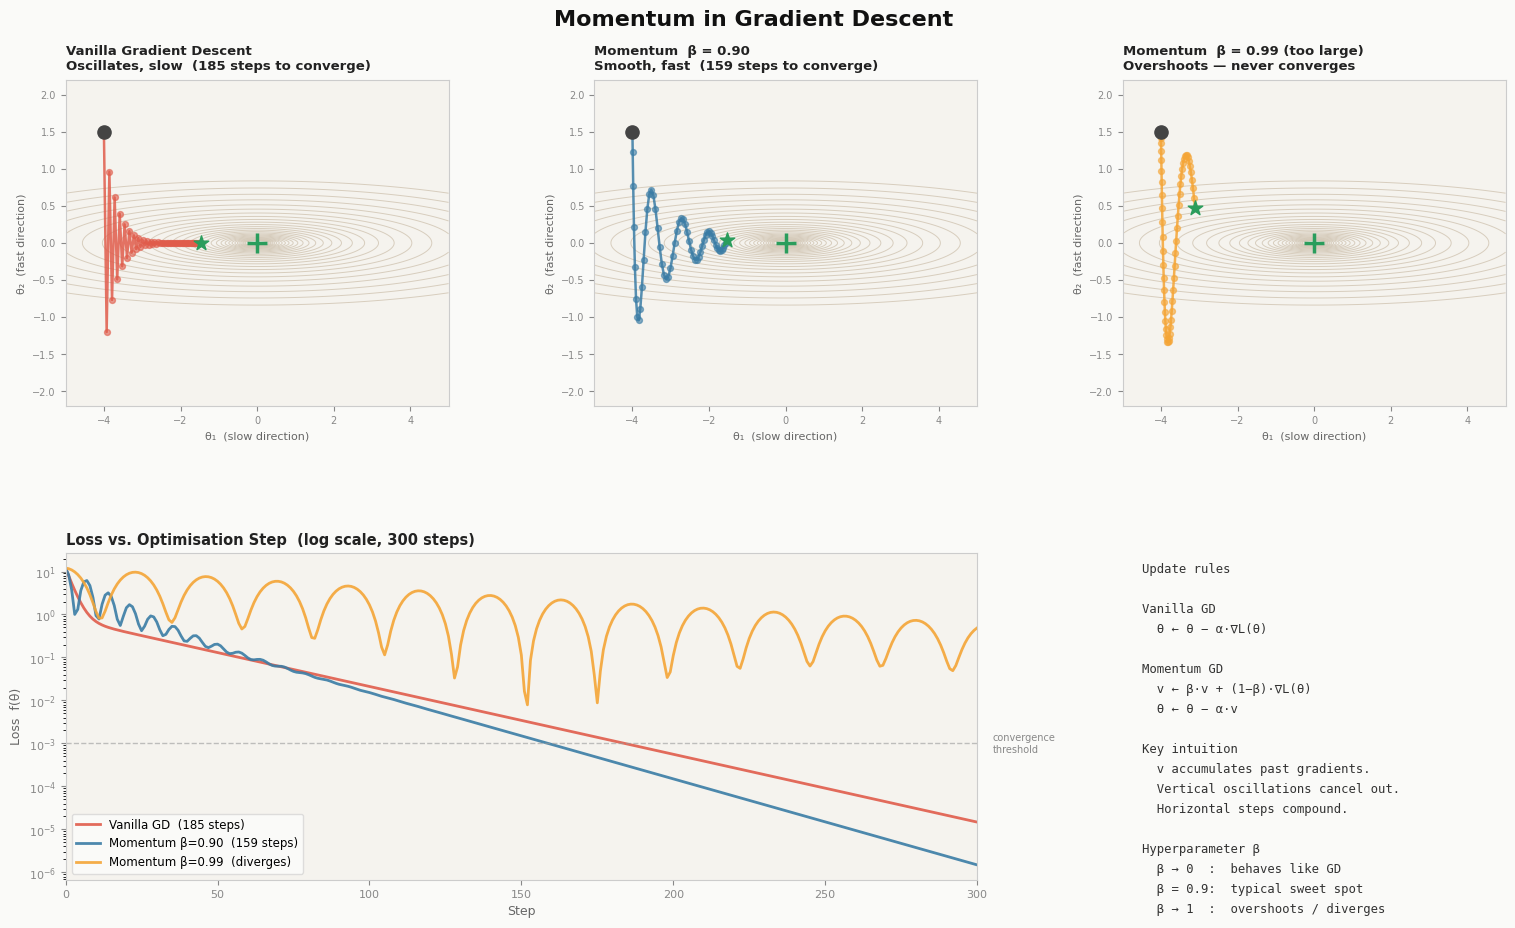

In [8]:
PLOT_STEPS = 55

x_ = np.linspace(-5, 5, 500)
y_ = np.linspace(-2.2, 2.2, 500)
X, Y = np.meshgrid(x_, y_)
Z    = loss(X, Y)

fig = plt.figure(figsize=(16, 10), facecolor="#FAFAF8")
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
               left=0.07, right=0.97, top=0.88, bottom=0.08)

COLORS = {
    "gd":        "#E05C4B",
    "mom_good":  "#3A7CA5",
    "mom_large": "#F4A536",
    "contour":   "#D4C9B8",
    "minima":    "#2A9D5C",
    "start":     "#444444",
}

PANEL_TITLES = [
    "Vanilla Gradient Descent\nOscillates, slow  (185 steps to converge)",
    "Momentum  β = 0.90\nSmooth, fast  (159 steps to converge)",
    "Momentum  β = 0.99 (too large)\nOvershoots — never converges",
]

paths_plot = [
    path_gd[:PLOT_STEPS+1],
    path_mom_good[:PLOT_STEPS+1],
    path_mom_large[:PLOT_STEPS+1],
]
colors = [COLORS["gd"], COLORS["mom_good"], COLORS["mom_large"]]

# top row: trajectory panels
for col, (path, color, title) in enumerate(zip(paths_plot, colors, PANEL_TITLES)):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor("#F5F3EE")

    levels = np.geomspace(0.005, 3.5, 28)
    ax.contour(X, Y, Z, levels=levels, colors=COLORS["contour"],
               linewidths=0.7, alpha=0.9)

    ax.plot(path[:, 0], path[:, 1], color=color, lw=1.8, alpha=0.85, zorder=3)
    ax.scatter(path[:, 0], path[:, 1], color=color, s=18, zorder=4, alpha=0.6)

    ax.scatter(*path[0],  marker="o", s=90,  color=COLORS["start"],  zorder=5, label="start")
    ax.scatter(*path[-1], marker="*", s=120, color=COLORS["minima"], zorder=5, label="end")
    ax.scatter(0, 0, marker="+", s=200, color=COLORS["minima"], linewidths=2.5, zorder=6)

    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(title, fontsize=9.5, fontweight="bold", color="#222", pad=7, loc="left")
    ax.set_xlabel("θ₁  (slow direction)", fontsize=8, color="#666")
    ax.set_ylabel("θ₂  (fast direction)", fontsize=8, color="#666")
    ax.tick_params(labelsize=7, colors="#888")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

# bottom-left: loss curves (full 300 steps)
ax_loss = fig.add_subplot(gs[1, :2])
ax_loss.set_facecolor("#F5F3EE")

full_paths  = [path_gd, path_mom_good, path_mom_large]
full_labels = ["Vanilla GD  (185 steps)", "Momentum β=0.90  (159 steps)", "Momentum β=0.99  (diverges)"]

for path, color, label in zip(full_paths, colors, full_labels):
    losses = [loss(*p) for p in path]
    steps_range = np.arange(len(path))
    ax_loss.plot(steps_range, losses, color=color, lw=2, label=label, alpha=0.9)

ax_loss.axhline(0.001, color="#999", lw=1, ls="--", alpha=0.6)
ax_loss.text(305, 0.001, "convergence\nthreshold", fontsize=7, color="#888", va="center")

ax_loss.set_yscale("log")
ax_loss.set_xlim(0, STEPS)
ax_loss.set_title("Loss vs. Optimisation Step  (log scale, 300 steps)",
                  fontsize=10.5, fontweight="bold", color="#222", loc="left")
ax_loss.set_xlabel("Step", fontsize=9, color="#666")
ax_loss.set_ylabel("Loss  f(θ)", fontsize=9, color="#666")
ax_loss.legend(fontsize=8.5, framealpha=0.6)
ax_loss.tick_params(labelsize=8, colors="#888")
for spine in ax_loss.spines.values():
    spine.set_edgecolor("#CCCCCC")

# bottom-right: annotation panel
ax_ann = fig.add_subplot(gs[1, 2])
ax_ann.set_facecolor("#F5F3EE")
ax_ann.axis("off")

annotation = (
    "Update rules\n\n"
    "Vanilla GD\n"
    "  θ ← θ − α·∇L(θ)\n\n"
    "Momentum GD\n"
    "  v ← β·v + (1−β)·∇L(θ)\n"
    "  θ ← θ − α·v\n\n"
    "Key intuition\n"
    "  v accumulates past gradients.\n"
    "  Vertical oscillations cancel out.\n"
    "  Horizontal steps compound.\n\n"
    "Hyperparameter β\n"
    "  β → 0  :  behaves like GD\n"
    "  β = 0.9:  typical sweet spot\n"
    "  β → 1  :  overshoots / diverges"
)
ax_ann.text(0.05, 0.97, annotation, transform=ax_ann.transAxes,
            fontsize=8.8, va="top", ha="left",
            fontfamily="monospace", color="#333", linespacing=1.7)

fig.suptitle("Momentum in Gradient Descent",
             fontsize=16, fontweight="bold", color="#111", y=0.95)

plt.savefig("momentum_explainer.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## β sensitivity sweep
The experiment runs the momentum optimizer multiple times with different β values, each for up to 500 steps. For every run, it checks when the loss first drops below 0.001 and records that step as the convergence point. β = 0 serves as a baseline, since it removes the effect of momentum and behaves exactly like vanilla gradient descent.

The results show a clear pattern. As β increases from 0.0 to 0.95, convergence steadily improves, with fewer steps needed each time. This happens because higher β values better smooth out oscillations and build useful momentum in the right direction. However, at β = 0.99, performance drops sharply. The optimizer becomes too slow to adjust because it relies too heavily on past gradients, leading to excessive overshooting and delayed convergence. Overall, this creates an inverted U-shaped relationship: moderate β values (around 0.9–0.95) give the best performance, while values that are too high can hurt convergence significantly.

In [9]:
THRESHOLD = 0.001
betas = [0.0, 0.5, 0.7, 0.85, 0.90, 0.95, 0.99]

print(f"\n── β Sensitivity  (steps to loss < {THRESHOLD}) ───────────────")
print(f"{'β':>6}  {'steps':>10}  note")
print("─" * 46)

for b in betas:
    path = momentum_gd(START, lr=LR, beta=b, steps=500)
    losses = [loss(*p) for p in path]
    hit = next((i for i, l in enumerate(losses) if l < THRESHOLD), None)
    note = ""
    if b == 0.0:  note = "← equivalent to vanilla GD"
    elif b == 0.90: note = "← typical sweet spot"
    elif b == 0.99: note = "← overshoots / diverges"
    status = f"{hit:>6} steps" if hit else "  did not converge"
    print(f"{b:>6.2f}  {status}  {note}")


── β Sensitivity  (steps to loss < 0.001) ───────────────
     β       steps  note
──────────────────────────────────────────────
  0.00     185 steps  ← equivalent to vanilla GD
  0.50     182 steps  
  0.70     179 steps  
  0.85     170 steps  
  0.90     159 steps  ← typical sweet spot
  0.95     129 steps  
  0.99     408 steps  ← overshoots / diverges


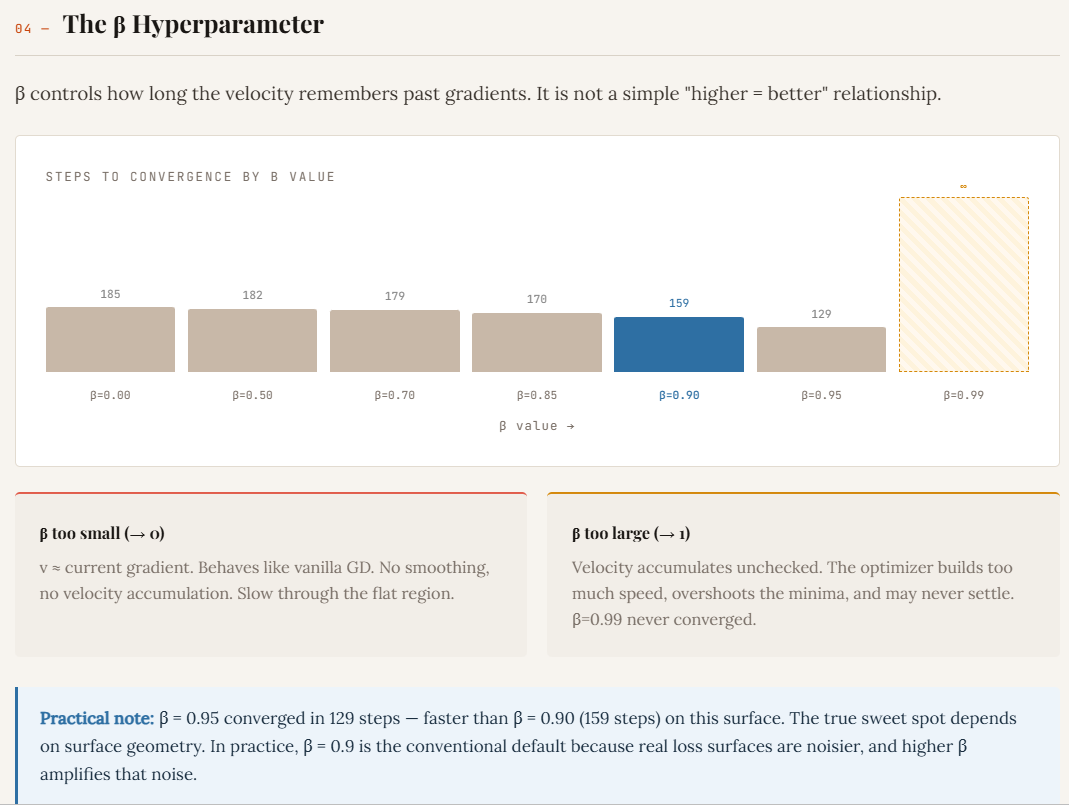